# Introduction to Mathematical Modelling

**by Dr Kamil Erguler**  
Climate and One Health Group  
CARE-C - The Cyprus Institute

---

[Previous (Introduction)](https://veclim.com/tutorials-viewer/localfile/MathMod/T00_IMM_intro.ipynb) --- Next (?)

<a href="https://www.dndbeyond.com/en/how-to-play-dnd" target="_blank" rel="noopener noreferrer">**Dungeons & Dragons**</a> is a fantasy role-playing game in which a team of imaginary characters are guided by a Dungeon Master (DM) through extraordinary journeys, challenging missions, dangerous encounters, and unexpected stories. The world can be as rich and strange as the players can imagine, but it is held together by rules and by rolls of dice.

DMs can be quite eccentric, and sometimes almost out of this world themselves. Let us try to persuade one to play with us.

> Welcome, strangers. I will guide you through the dungeons if you win this game first. I will choose one of these three dice — a 4-sided, a 6-sided, or a 20-sided die — and you will guess which one it is from the throws. If you guess correctly in under ten throws, I will be your DM.

She then rolls the die one step at a time, asking after each roll whether we wish to guess or need another roll:
```r
1, 3, 3, 2, 1, 3, 2, 4
```


## Models as hypotheses

> “This ideal theoretical model cannot probably be achieved. Partial models, imperfect as they may be, are the only means developed by science for understanding the universe.”
>
> — Arturo Rosenblueth and Norbert Wiener, **The Role of Models in Science**, *Philosophy of Science*, 1945.

Let us idealise the situation. All models are incomplete by design: they simplify the world by leaving things out. So, our goal is not to reproduce reality perfectly, but to construct a useful approximation of it.

We will build three models, one for each die, under the following fair conditions:

- each die is perfect, with no physical flaws;
- each side has the same probability of appearing;
- the table and surrounding environment do not affect the outcome;
- the way the die is rolled does not affect the outcome.

Under these assumptions:

- the 4-sided die, `d4`, gives each of `1, 2, 3, 4` with probability `1/4`;
- the 6-sided die, `d6`, gives each of `1, 2, 3, 4, 5, 6` with probability `1/6`;
- the 20-sided die, `d20`, gives each of `1, 2, ..., 20` with probability `1/20`.


## Evaluating support

Under these assumptions, we are interested in evaluating the relative support that the data provide for each model, that is,

$P(M_i \mid \delta)$,

where $M_i$ is the $i^{\text{th}}$ model and $\delta$ is the set of observations.

We cannot evaluate this probability directly, but we can calculate the reverse conditional probability, $P(\delta \mid M_i)$, which is referred to as **the likelihood**. The relationship between the two is given by Bayes' formula:

$
P(M_i \mid \delta) = \frac{P(\delta \mid M_i)P(M_i)}{P(\delta)} = \frac{P(\delta \mid M_i)P(M_i)}{\sum_j P(\delta \mid M_j)P(M_j)}.
$

In this relationship, $P(M_i)$ is called **the prior**, representing our support for model $M_i$ before considering the observations $\delta$. It may implicitly rely on previous observations and assumptions, so that $P(M_i) = P(M_i \mid x)$, where $x$ represents all information available before $\delta$.

Here, $P(\delta)$ is the probability of observing the data under all proposed models — in this case, $M_{d4}$, $M_{d6}$, and $M_{d20}$. Although it is often treated as a normalising factor, rescaling the values so that $P(M_i \mid \delta)$ is a proper probability, it represents how probable the observed data are under the whole set of proposed models.

In a discrete model space, $P(\delta)$ is evaluated by summing over the proposed models:

$
P(\delta) = \sum_j P(\delta \mid M_j)P(M_j).
$

In a continuous proposal space, the corresponding operation would be integration.

Often, when we are only interested in comparing the relative support for each model, this normalising factor is left implicit:

$
P(M_i \mid \delta) \propto P(\delta \mid M_i)P(M_i).
$


## The first die roll

Let us say that, before receiving even a single die roll, we have no reason to prefer one die over the other two. Therefore, for the first observation, `1`,

$
P(M_{d4} \mid \delta=1) = \frac{P(\delta=1 \mid M_{d4})P(M_{d4})}{P(\delta=1 \mid M_{d4})P(M_{d4})+P(\delta=1 \mid M_{d6})P(M_{d6})+P(\delta=1 \mid M_{d20})P(M_{d20})}.
$

Substituting the values gives

$
P(M_{d4} \mid \delta=1) = \frac{\frac{1}{4}\times\frac{1}{3}}{\frac{1}{4}\times\frac{1}{3}+\frac{1}{6}\times\frac{1}{3}+\frac{1}{20}\times\frac{1}{3}} = 0.535714.
$

This is **the posterior** probability after observing the data. Notice how it has increased from `0.333333` to `0.535714`. Comparing this with the other models,

$
P(M_{d4} \mid \delta=1) = 0.535714,
$

$
P(M_{d6} \mid \delta=1) = 0.357143,
$

$
P(M_{d20} \mid \delta=1) = 0.107143.
$

At this point, `d4` seems to be the most likely choice. Rather than repeating this calculation by hand, let us write an R script to update our belief as we receive more rolls.


## Automating the process

In [3]:
# To assume that all models are equally likely a priori
uniform_prior <- function() {
    prior <- c()
    for (m in names(likelihoods)) {
      prior[m] <- 1 / length(likelihoods)
    }
    return(prior)
}

# Updating a prior belief on the basis of an observation
bayesian_update <- function(observation, prior) {
    unnormalised <- c()
    for (model in names(likelihoods)) {
        likelihood <- likelihoods[[model]]
        
        # Probability of the new observation under each model
        like <- likelihood(observation)

        # Unnormalised posterior
        unnormalised[model] <- like * prior[model]
    }

    # Normalise, with probability of observations, so that probabilities add up to 1
    posterior <- unnormalised / sum(unnormalised)

    return(posterior)
}

In [2]:
# Probability of observing x under a die model
likelihoods <- c("d4" = function(x) { return (ifelse(x >= 1 && x <= 4, 1 / 4, 0)) },
                 "d6" = function(x) { return (ifelse(x >= 1 && x <= 6, 1 / 6, 0)) }, 
                 "d20" = function(x) { return (ifelse(x >= 1 && x <= 20, 1 / 20, 0)) })

We now apply the updating procedure to the original sequence:

```r
1, 3, 3, 2, 1, 3, 2, 4
```

                 d4       d6      d20
Prior      0.333333 0.333333 0.333333
Data 1 : 1 0.535714 0.357143 0.107143
Data 2 : 3 0.673653 0.299401 0.026946
Data 3 : 3 0.766697 0.227169 0.006134
Data 4 : 2 0.833937 0.164728 0.001334
Data 5 : 1 0.883387 0.116331 0.000283
Data 6 : 3 0.919240 0.080701 0.000059
Data 7 : 2 0.944697 0.055291 0.000012
Data 8 : 4 0.962444 0.037553 0.000002


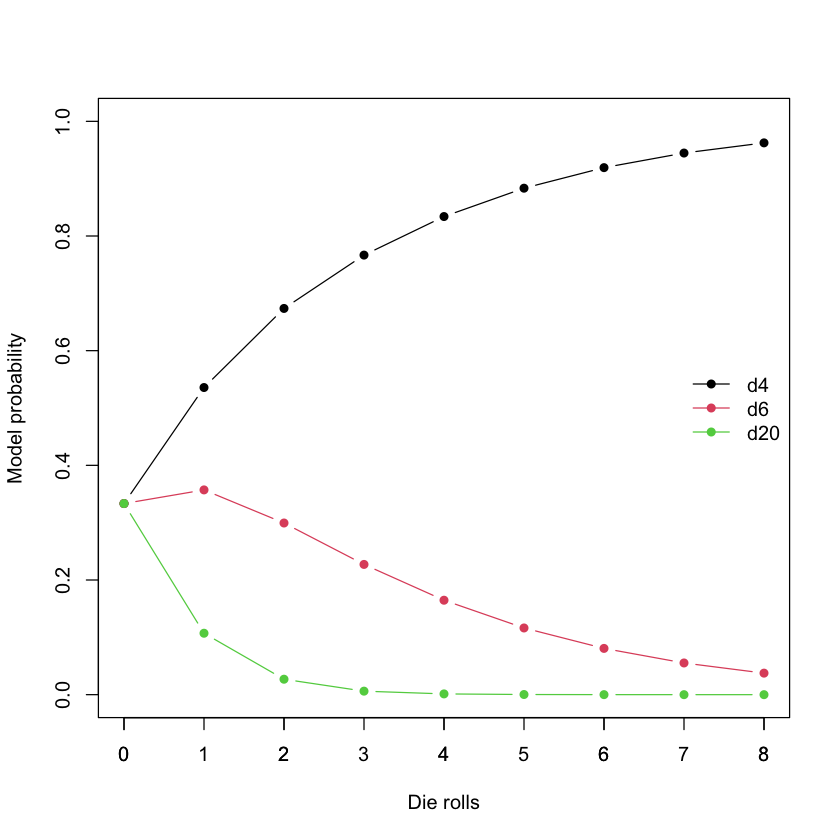

In [3]:
# Observed sequence
observations <- c(1, 3, 3, 2, 1, 3, 2, 4)

model_probabilities <- matrix(
    nrow = length(observations)+1,
    ncol = length(names(likelihoods))
  )
  colnames(model_probabilities) <- names(likelihoods)
  rownames(model_probabilities) <- c("Prior", paste("Data",1:length(observations),":",as.character(observations))
)

current_prior <- uniform_prior()
model_probabilities[1,] <- current_prior
for (m in seq_along(observations)) {
    current_prior <- bayesian_update(observations[m], current_prior)
    model_probabilities[m+1, ] <- current_prior
}

print(round(model_probabilities, 6))

steps <- 0:(nrow(model_probabilities) - 1)

par(bg = "white")

matplot(steps, model_probabilities, type = "b", pch = 16, lty = 1, ylim = c(0, 1), xlab = "Die rolls", ylab = "Model probability")

axis(side = 1, at = steps)

legend("right", legend = colnames(model_probabilities), lty = 1, pch = 16, col = 1:ncol(model_probabilities), bty = "n")

`d4` is the best-supported model after the first roll. Why? Notice that `d20` has 20 sides, which makes it much less likely to produce a value in the range `1–4`. In fact, it is four times more likely to produce a value outside this range than inside it. This larger set of possible outcomes is naturally penalised during Bayesian updating. There is no need to introduce an additional measure of parsimony.

By the second roll, it already becomes clear that the die is most likely `d4`. But if you would like to be more confident, and you are allowed more rolls, you can simply ask for more evidence. After the final roll, the posterior probability of `d4` is 0.962444. In this Bayesian sense, we can say that we are about 96.2% confident that the DM chose the 4-sided die. The remaining uncertainty, about 3.8%, is mostly assigned to `d6`, while `d20` has become almost impossible under the observed sequence.

> This is an important point: the model probabilities are conditional on the observations seen so far and on the set of models we decided to compare.


## The data do not care about our assumptions

Nevertheless, mostly to rule out `d6`, we asked the DM for one more roll. The full sequence is now:

```r
1, 3, 3, 2, 1, 3, 2, 4, 10
```

Although the first eight rolls strongly supported the 4-sided die, the final observation, `10`, is impossible under both the 4-sided and 6-sided die models.

This is where things become interesting.

In [4]:
rbind(
    current_prior,
    bayesian_update(10, current_prior)
)

,d4,d6,d20
current_prior,0.9624445,0.03755308,2.463858e-06
,0.0000000,0.00000000,1.000000e+00



## An interlude

If you have never been to Australia, chances are you have never seen a black swan. For a long time, Europeans treated the black swan as a symbol of something impossible: all the swans they knew were white, so a black swan seemed not to exist at all. The expression goes back at least to the Roman poet Juvenal, who used the image of a black swan as an impossibly rare bird.

That certainty collapsed in 1697, when the Dutch explorer Willem de Vlamingh encountered black swans in Western Australia, on the river later named the Swan River. A single observation was enough to challenge what had seemed like a universal rule.

Much later, Nassim Nicholas Taleb popularised the term **Black Swan** for an event that lies outside regular expectations, has a major impact, and is often explained afterwards as if it should have been expected all along.

This is a useful reminder for modelling: the data do not care about the limits of our assumptions.


## What now?

In our example, after the first eight observations, the 4-sided die appears overwhelmingly plausible. The 20-sided die has not been eliminated, but its posterior probability has become extremely small.

Then a single `10` appears.

This final observation is impossible under both the 4-sided and the 6-sided die models, leaving the 20-sided die as the only possible explanation among the models we proposed.

This teaches two important modelling lessons:

1. A model can be strongly supported by many observations and still be overturned by a single observation that it cannot explain.
2. Posterior probabilities are conditional on both the data observed so far and the models included in the comparison.


## Is there a better explanation?

What about observational noise? How much do we trust the DM? Perhaps she is telling the truth, or perhaps she is deliberately misleading us to get us off her back.

The models we have considered so far are based on complete trust in the rules of the game. But maybe the rules have been bent.

Let us see.

If every reported outcome were arbitrary, then there would be no way to infer anything. The sequence would contain no information about the die.

Instead, let us propose alternative versions of the three die models, allowing for some degree of distrust in the outcomes reported by the DM. Yes, there are many other ways she could cheat or misreport the rolls, but remember that this is only a demonstration of some modelling principles. So, follow my lead.

Let us introduce a global parameter: `p.cheat`, the probability that the DM lies about a roll.

For example, if `p.cheat = 0.25`, then on average the DM lies about one in every four rolls. When she lies, we assume that the reported outcome is chosen independently of the die, with each number from `1` to `20` having probability `1/20`.

In [1]:
p.cheat <- 0.25

# Probability of observing x under a die model
likelihoods <- c("d4" = function(x) { return (ifelse(x >= 1 && x <= 4, 1 / 4, 0)) },
                 "d6" = function(x) { return (ifelse(x >= 1 && x <= 6, 1 / 6, 0)) }, 
                 "d20" = function(x) { return (ifelse(x >= 1 && x <= 20, 1 / 20, 0)) },
                 #
                 # Here are the new "cheat" models, which have a probability of p.cheat of producing any observation, 
                 # and a probability of (1 - p.cheat) of producing an observation according to the original die model
                 #
                 "d4.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 4, 1 / 4, 0))) },
                 "d6.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 6, 1 / 6, 0))) },
                 "d20.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 20, 1 / 20, 0))) })

                  d4       d6      d20 d4.cheat d6.cheat d20.cheat
Prior       0.166667 0.166667 0.166667 0.166667 0.166667  0.166667
Data 1 : 1  0.292683 0.195122 0.058537 0.234146 0.160976  0.058537
Data 2 : 3  0.405360 0.180160 0.016214 0.259430 0.122621  0.016214
Data 3 : 3  0.502343 0.148842 0.004019 0.257200 0.083577  0.004019
Data 4 : 2  0.587600 0.116069 0.000940 0.240681 0.053769  0.000940
Data 5 : 1  0.662104 0.087191 0.000212 0.216958 0.033323  0.000212
Data 6 : 3  0.725824 0.063721 0.000046 0.190270 0.020091  0.000046
Data 7 : 2  0.779124 0.045600 0.000010 0.163394 0.011862  0.000010
Data 8 : 4  0.822931 0.032109 0.000002 0.138065 0.006891  0.000002
Data 9 : 10 0.000000 0.000000 0.000058 0.952352 0.047531  0.000058


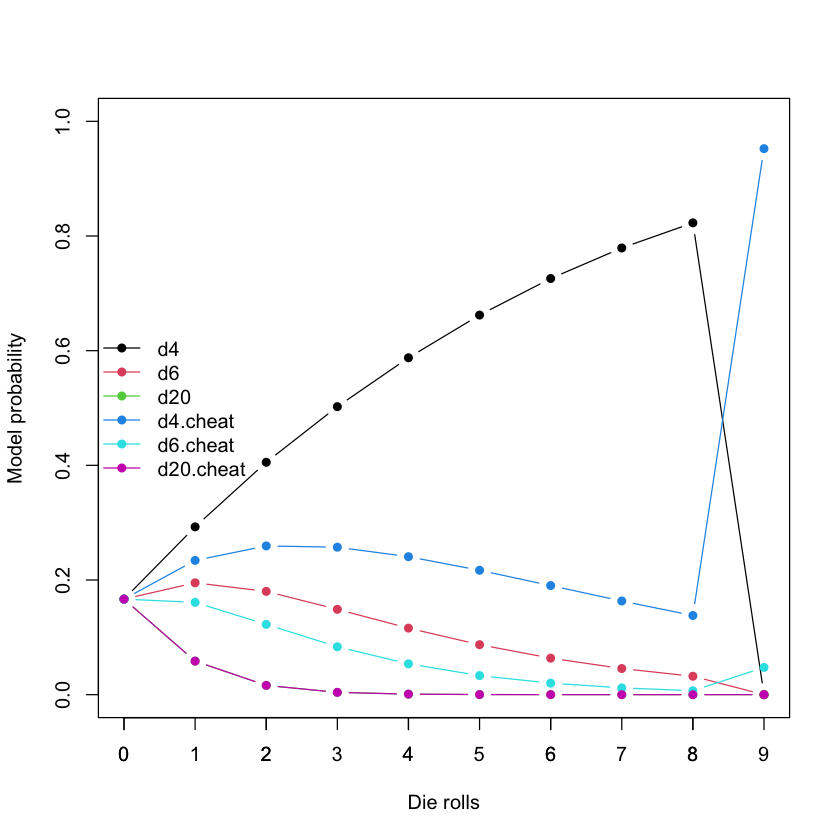

In [4]:
# Observed sequence
observations <- c(1, 3, 3, 2, 1, 3, 2, 4, 10)

model_probabilities <- matrix(
    nrow = length(observations)+1,
    ncol = length(names(likelihoods))
  )
  colnames(model_probabilities) <- names(likelihoods)
  rownames(model_probabilities) <- c("Prior", paste("Data",1:length(observations),":",as.character(observations))
)

current_prior <- uniform_prior()
model_probabilities[1,] <- current_prior
for (m in seq_along(observations)) {
    current_prior <- bayesian_update(observations[m], current_prior)
    model_probabilities[m+1, ] <- current_prior
}

print(round(model_probabilities, 6))

steps <- 0:(nrow(model_probabilities) - 1)

par(bg = "white")

matplot(steps, model_probabilities, type = "b", pch = 16, lty = 1, ylim = c(0, 1), xlab = "Die rolls", ylab = "Model probability")

axis(side = 1, at = steps)

legend("left", legend = colnames(model_probabilities), lty = 1, pch = 16, col = 1:ncol(model_probabilities), bty = "n")

Under `p.cheat = 0.25`, support for the honest `d4` model increases until the final roll. The last observation, `10`, makes the honest `d4` model impossible and assigns the highest probability to `d4.cheat`. We therefore still conclude that the most likely explanation for the observed sequence is that the DM was using the 4-sided die, but lied about the final roll.

Under these conditions, `10` may no longer seem like such a **Black Swan**. But remember, it was the appearance of `10` that made us question our belief and look for better explanations for what we had been told.